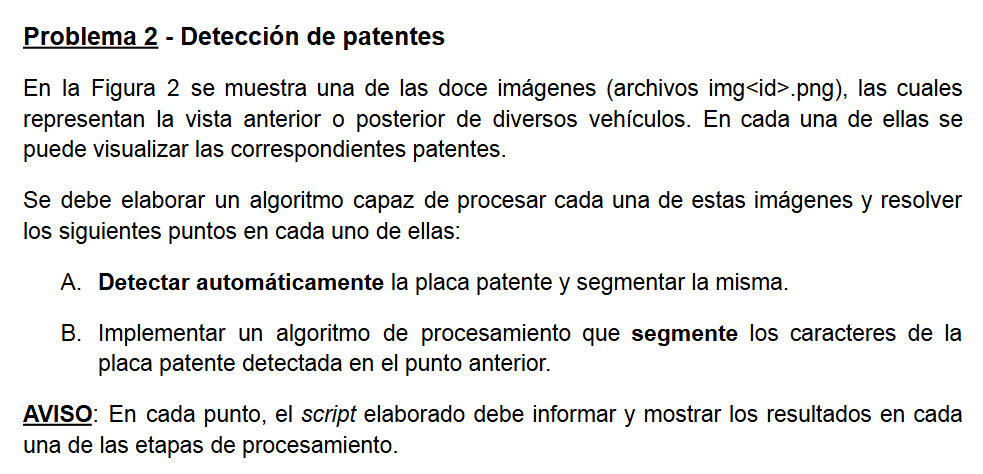

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

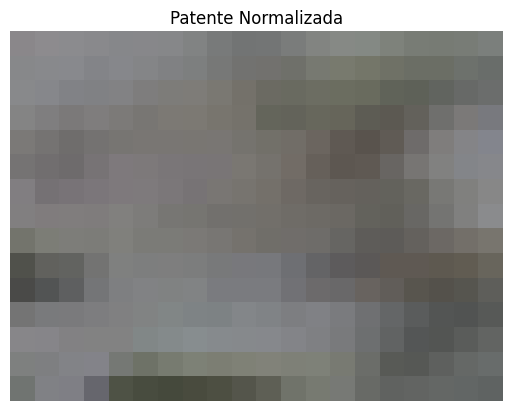

array([[[138, 135, 138],
        [142, 139, 141],
        [142, 139, 139],
        [140, 137, 137],
        [138, 135, 134],
        [138, 135, 135],
        [137, 135, 134],
        [131, 131, 129],
        [122, 122, 120],
        [116, 116, 114],
        [117, 117, 115],
        [123, 124, 122],
        [129, 132, 130],
        [133, 137, 134],
        [132, 137, 132],
        [123, 130, 126],
        [117, 124, 120],
        [116, 123, 119],
        [118, 124, 120],
        [124, 127, 123]],

       [[138, 136, 135],
        [140, 137, 136],
        [141, 137, 136],
        [136, 132, 131],
        [139, 135, 134],
        [135, 133, 132],
        [131, 129, 128],
        [127, 127, 125],
        [119, 120, 119],
        [112, 114, 114],
        [110, 113, 114],
        [106, 112, 111],
        [113, 121, 119],
        [110, 122, 120],
        [105, 118, 116],
        [102, 113, 111],
        [101, 110, 107],
        [101, 110, 107],
        [108, 113, 109],
        [106, 109, 105]

In [453]:
def detectar_patente(ruta_imagen, min_area, max_area):

    img = cv2.imread(ruta_imagen)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    filtered = cv2.bilateralFilter(gray, 11, 17, 17)
    edged = cv2.Canny(filtered, 25, 150) 

    kernel = np.ones((3, 3), np.uint8)
    clausura = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)

    contours, hierarchy = cv2.findContours(clausura.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    patente_contorno = None
    
    for c in contours:

        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.055* perimeter, True) 
        
        if area <min_area or area > max_area: 
            if len(approx) == 4:
                x, y, w, h = cv2.boundingRect(approx)
                aspect_ratio = w / float(h)
                
                if 1.5 <= aspect_ratio <= 3.5:
                    patente_contorno = approx
                    break 
    
    if patente_contorno is not None:
        
        def order_points(pts):
            rect = np.zeros((4, 2), dtype="float32")
            
            s = pts.sum(axis=1)
            rect[0] = pts[np.argmin(s)] 
            rect[2] = pts[np.argmax(s)] 

            diff = np.diff(pts, axis=1)
            rect[1] = pts[np.argmin(diff)] 
            rect[3] = pts[np.argmax(diff)] 

            return rect

        pts = patente_contorno.reshape(4, 2)
        rect = order_points(pts)
        (tl, tr, br, bl) = rect

        max_ancho = max(int(np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))), 
                                    int(np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))))
        
        max_alto = max(int(np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))), 
            int(np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))))

        dst = np.array([[0, 0],[max_ancho - 1, 0],[max_ancho - 1, max_alto - 1],[0, max_alto - 1]], dtype="float32")
        M = cv2.getPerspectiveTransform(rect, dst)
        patente_normalizada = cv2.warpPerspective(img, M, (max_ancho, max_alto))

        plt.imshow(cv2.cvtColor(patente_normalizada, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Patente Normalizada')
        plt.show() 
        

        return patente_normalizada

detectar_patente('img/img12.png', 3550,15000)



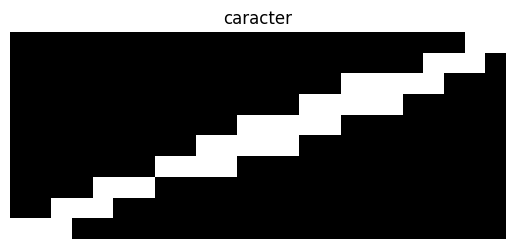

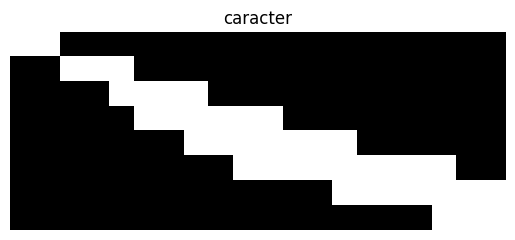

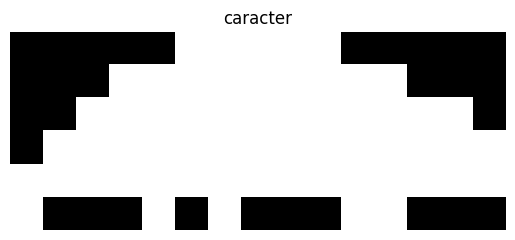

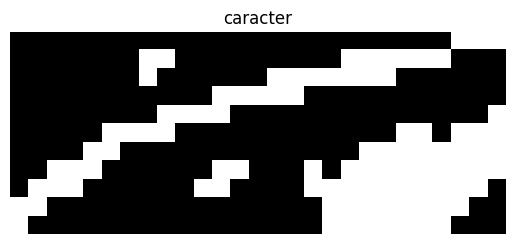

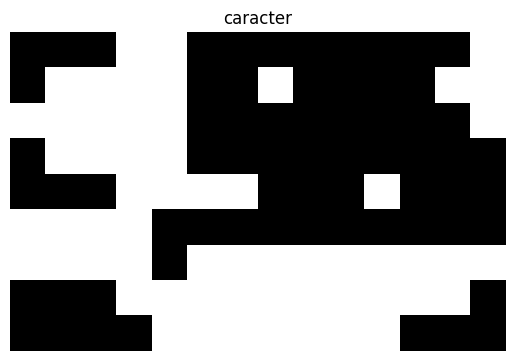

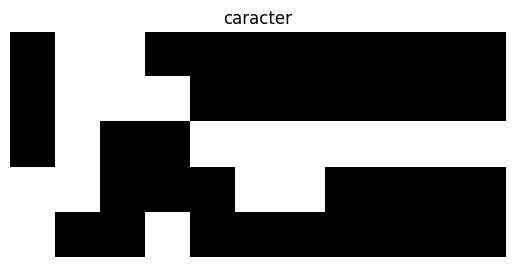

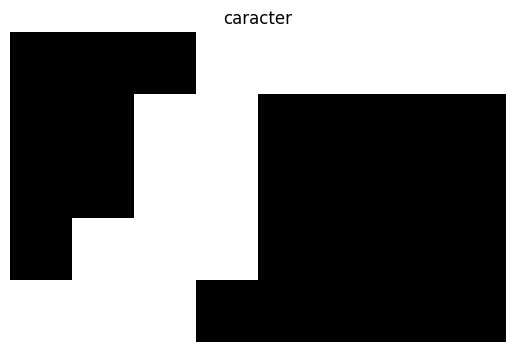

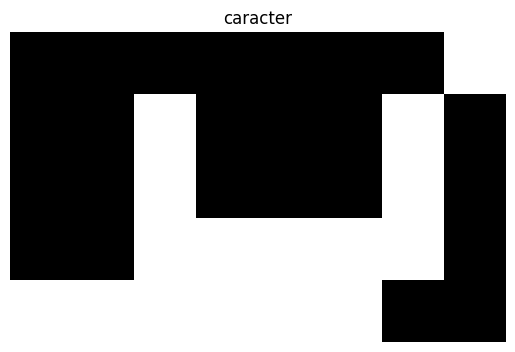

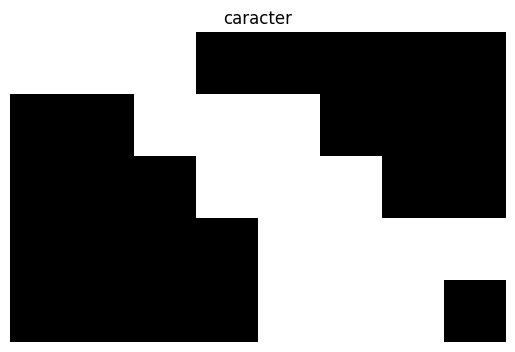

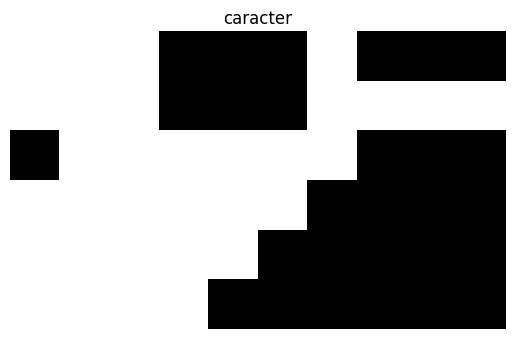

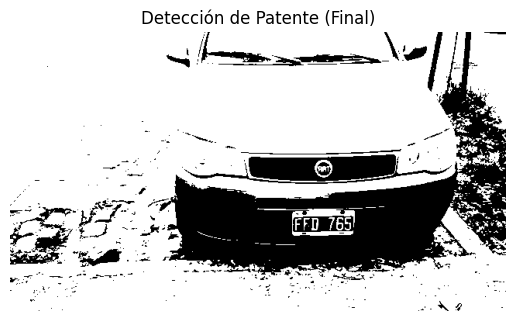

[]

In [530]:

def detectar_patente_final(ruta_imagen,thresh, MIN_AREA_CHARACTER,MAX_AREA_CHARACTER,MIN_HEIGHT_CHARACTER,MAX_WIDTH_CHARACTER):
    
    img = cv2.imread(ruta_imagen)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, patente_binaria = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY_INV) 
    #kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
    #patente_solida = cv2.morphologyEx(patente_binaria, cv2.MORPH_CLOSE, kernel)
    invertida = cv2.bitwise_not(patente_binaria)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(patente_binaria, 8, cv2.CV_32S)

    objetos_stats = stats[1:]

    if len(objetos_stats) == 0:
        return (f"Cantidad total de caracteres: 0",
                f"Cantidad de espacios 'en blanco' (separaciones entre palabras): 0",
                f"Cantidad de palabras formadas: 0")

    componentes_validas = []
    UMBRAL_ESPACIO_FIJO = 8
    for s in objetos_stats:
        x, y, w, h, area = s[0], s[1], s[2], s[3], s[4]
        aspect_ratio = w / h if h != 0 else 0

        if (area >= MIN_AREA_CHARACTER and area <= MAX_AREA_CHARACTER and
            h >= MIN_HEIGHT_CHARACTER and 1.5 < aspect_ratio <3.0):
            #componentes_validas.append({'x': x, 'x_fin': x + w})

            crop_caracter = patente_binaria[y:y + h, x:x + w]

            plt.imshow(cv2.cvtColor(crop_caracter, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title('caracter')
            plt.show()


    plt.imshow(cv2.cvtColor(invertida, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Detección de Patente (Final)")
    plt.show()

    return  componentes_validas

detectar_patente_final('img/img09.png', 90,15, 90, 5,70)

In [ ]:
detectar_patente_final('img/img05.png',200, 15000, 10,5500)

num_labels_crop, labels_crop, stats_crop, centroids_crop = cv2.connectedComponentsWithStats(crop_caracter, 8, cv2.CV_32S)
            objetos_stats_crop = stats_crop[1:] 
            componentes_validas_crop = []

            for s_crop in objetos_stats_crop:
                x_crop, y_crop, w_crop, h_crop, area_crop = s_crop[0], s_crop[1], s_crop[2], s_crop[3], s_crop[4]
                aspect_ratio_crop = w_crop / h_crop if h_crop != 0 else 0

                if (area_crop >= MIN_AREA_CHARACTER and area_crop <= MAX_AREA_CHARACTER and
                            h_crop >= MIN_HEIGHT_CHARACTER and w_crop <= MAX_WIDTH_CHARACTER and 1.5 < aspect_ratio <3.0 ):
                            componentes_validas.append({'x': x_crop, 'x_fin': x_crop + w_crop})
                            crop_caracter_final = crop_caracter[y_crop:y_crop + h_crop, x_crop:x_crop + w_crop]

                            #break
                            componentes_ordenadas = sorted(componentes_validas_crop, key=lambda c: c['x'])
                            cantidad_caracteres = len(componentes_ordenadas)
                            
                            if cantidad_caracteres <= 1:
                                return (cantidad_caracteres, cantidad_caracteres)

                            espacios_en_blanco = 0
                            palabras_formadas = 1


                            for i in range(cantidad_caracteres - 1):
                                comp_actual = componentes_ordenadas[i]
                                comp_siguiente = componentes_ordenadas[i+1]

                                distancia = comp_siguiente['x'] - comp_actual['x_fin']

                                if distancia >= UMBRAL_ESPACIO_FIJO:
                                    espacios_en_blanco += 1
                                    palabras_formadas += 1
                            

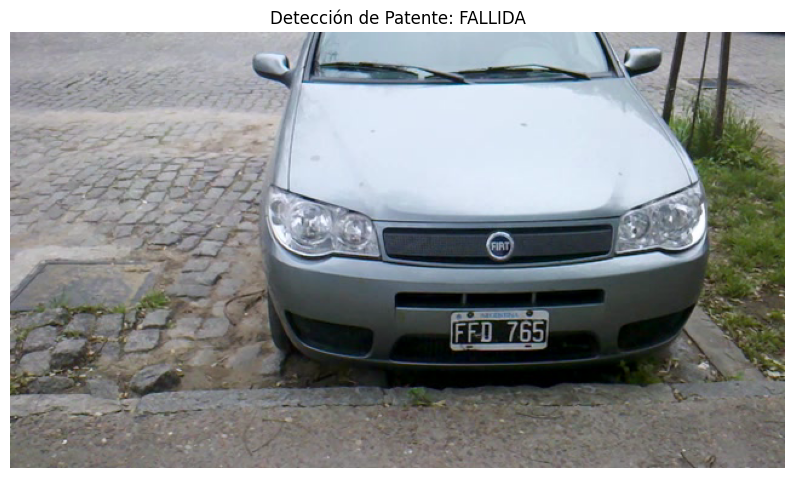

         Objeto  Cantidad
0  NO DETECTADA         1
TOTAL DETECCIONES DE PLACA: 0


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def detectar_placa_y_segmentar_caracteres_v3(ruta_imagen):
    
    img = cv2.imread(ruta_imagen)
    if img is None:
        print("Error: Imagen no encontrada")
        return pd.DataFrame(), 0.0

    output_image = img.copy()
    data_lista = []
    
    # 1. Preprocesamiento: Resaltar bordes
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 13, 20, 20) # Aumentado el tamaño del kernel para mejor suavizado
    
    # Detección de Bordes Canny (Umbrales más permisivos para captar bordes más débiles)
    edged = cv2.Canny(gray, 40, 200) # Umbral inferior ajustado de 60 a 40

    # Operación Morfológica para conectar bordes horizontales de la placa
    # Kernel ligeramente más grande para conectar mejor fragmentos dispersos
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 7)) # Tamaño ajustado
    mask_closed = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)
    
    # Búsqueda de Contornos
    contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Ordenar contornos por área de mayor a menor y considerar un número limitado
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:20] # Considerar más contornos

    # Parámetros de Filtrado para Patentes (Ajustados para mayor flexibilidad)
    img_h, img_w, _ = img.shape
    
    MIN_AREA_PLACA = int(img_w * img_h * 0.005) # Área mínima (0.5% del área total de la imagen)
    MAX_AREA_PLACA = int(img_w * img_h * 0.04)  # Área máxima (4% del área total de la imagen)
    MIN_ASPECT_RATIO = 2.8 # Relación Ancho/Alto típica de una placa (más flexible)
    MAX_ASPECT_RATIO = 6.0
    MIN_SOLIDITY = 0.70    # Solidez mínima (más permisiva)

    placa_detectada = False
    best_placa_contorno = None
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < MIN_AREA_PLACA or area > MAX_AREA_PLACA: 
            continue 
        
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Filtrar por Posición (Más específico para esta imagen)
        # La patente está aproximadamente en el rango vertical 0.60 a 0.85 del total de la imagen
        # Y cerca del centro horizontal
        if not (y > img_h * 0.55 and (y + h) < img_h * 0.85): # Ajustado para la imagen del Fiat
            continue
        if not (abs(x + w/2 - img_w/2) / img_w < 0.25): # Cerca del centro horizontal
            continue
            
        # Relación de Aspecto
        aspect_ratio = w / h if h != 0 else 0
        if not (MIN_ASPECT_RATIO < aspect_ratio < MAX_ASPECT_RATIO):
            continue
        
        # Solidez
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        if not (solidity > MIN_SOLIDITY):
            continue
            
        # Si llegamos aquí, este contorno es un candidato fuerte.
        # Preferimos el contorno con el mejor ajuste (podríamos usar una métrica combinada)
        # Por ahora, tomaremos el primero que cumpla con todos.
        placa_detectada = True
        best_placa_contorno = cnt
        break
        
    if not placa_detectada:
        data_lista.append("NO DETECTADA")
        print("No se encontró ningún contorno que cumpla con los criterios de patente.")
        # Visualización de la imagen original con el título de fallo
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("Detección de Patente: FALLIDA")
        plt.show()
        return pd.DataFrame(), 0.0

    # Recortar la región de la placa detectada (Punto A resuelto)
    x, y, w, h = cv2.boundingRect(best_placa_contorno)
    placa_recortada_color = img[y:y+h, x:x+w]
    
    # --- PASO 4: Segmentación de Caracteres (Punto B) ---
    
    # Binarización con Otsu
    gray_placa = cv2.cvtColor(placa_recortada_color, cv2.COLOR_BGR2GRAY)
    _, patente_binaria = cv2.threshold(gray_placa, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    
    # Parámetros Dinámicos (relativos a la placa recortada)
    h_placa = patente_binaria.shape[0]
    
    MIN_AREA_CHAR = int(w * h * 0.005)
    MAX_AREA_CHAR = int(w * h * 0.25) # Aumentado el máximo para caracteres potencialmente más grandes
    MIN_HEIGHT_CHAR = int(h * 0.30)   # Más permisivo en altura mínima
    UMBRAL_ESPACIO = int(w * 0.02)

    # Componentes Conectadas y Filtrado
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(patente_binaria, 8, cv2.CV_32S)

    objetos_stats = stats[1:]
    centroids_data = centroids[1:]
    componentes_validas = []

    for i, s in enumerate(objetos_stats):
        x_char, y_char, w_char, h_char, area_char = s[0], s[1], s[2], s[3], s[4]
        cx_char = centroids_data[i][0]
        aspect_ratio_char = w_char / h_char if h_char != 0 else 0 
        
        if (area_char >= MIN_AREA_CHAR and area_char <= MAX_AREA_CHAR and
            h_char >= MIN_HEIGHT_CHAR and 
            0.1 < aspect_ratio_char < 1.0): 

            if x_char == 0 or y_char == 0 or (x_char + w_char) == w or (y_char + h_char) == h:
                continue
                
            componentes_validas.append({
                'x': x_char, 'y': y_char, 'w': w_char, 'h': h_char, 'area': area_char, 'cx': cx_char
            })

    # Ordenamiento y Conteo
    componentes_validas.sort(key=lambda c: c['x'])
    
    num_caracteres = len(componentes_validas)
    num_espacios = 0
    num_palabras = 0

    if num_caracteres > 0:
        num_palabras = 1
        for i in range(num_caracteres - 1):
            char_actual = componentes_validas[i]
            char_siguiente = componentes_validas[i+1]
            separacion = char_siguiente['x'] - (char_actual['x'] + char_actual['w'])

            if separacion >= UMBRAL_ESPACIO:
                num_espacios += 1
                num_palabras += 1

    # --- Visualización ---
    resumen = (
        f"Cantidad total de caracteres: {num_caracteres}\n"
        f"Cantidad de separaciones 'en blanco' (entre palabras): {num_espacios}\n"
        f"Cantidad de 'palabras' (grupos de caracteres): {num_palabras}"
    )

    img_draw_full = img.copy()
    cv2.drawContours(img_draw_full, [best_placa_contorno], -1, (0, 255, 0), 3)

    img_draw_placa = placa_recortada_color.copy()
    for c in componentes_validas:
        x_char, y_char, w_char, h_char = c['x'], c['y'], c['w'], c['h']
        cv2.rectangle(img_draw_placa, (x_char, y_char), (x_char + w_char, y_char + h_char), (255, 0, 0), 2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(cv2.cvtColor(img_draw_full, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Punto A: Placa Detectada (Contorno Verde)")
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(img_draw_placa, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Punto B: Caracteres Segmentados (Recorte)")
    axes[1].text(5, img_draw_placa.shape[0] - 10, resumen, color='yellow', fontsize=8, 
                 bbox=dict(facecolor='black', alpha=0.5))
    axes[1].axis('off')
        plt.show()

    data_lista.append("PATENTE DETECTADA" if placa_detectada else "NO DETECTADA")
    df = pd.DataFrame(data_lista, columns=['Objeto'])
    conteo_df = df['Objeto'].value_counts().reset_index(name='Cantidad')
    total = 1.0 if placa_detectada else 0.0

    return conteo_df, total

# --- Ejecución ---
# Usa la ruta de tu imagen, por ejemplo 'img/img09.png' si ese es el archivo del Fiat.
conteo_df_final, total_final = detectar_placa_y_segmentar_caracteres_v3('img/img09.png') # ¡Ajusta esta ruta!

print("\n--- Resultado Final ---")
print(conteo_df_final)
print(f"TOTAL DETECCIONES DE PLACA: {total_final:.0f}")

In [ ]:
import cv2
import numpy as np

# ============================================
#   FUNCIONES AUXILIARES
# ============================================

def ordenar_vertices(pts):
    pts = pts.reshape((4, 2))
    nuevo = np.zeros((4, 2), dtype=np.float32)

    s = pts.sum(axis=1)
    nuevo[0] = pts[np.argmin(s)]     # top-left
    nuevo[3] = pts[np.argmax(s)]     # bottom-right

    diff = np.diff(pts, axis=1)
    nuevo[1] = pts[np.argmin(diff)]  # top-right
    nuevo[2] = pts[np.argmax(diff)]  # bottom-left

    return nuevo


def corregir_perspectiva(img, pts):
    pts = ordenar_vertices(pts)
    (tl, tr, bl, br) = pts

    anchoA = np.linalg.norm(br - bl)
    anchoB = np.linalg.norm(tr - tl)
    max_ancho = int(max(anchoA, anchoB))

    altoA = np.linalg.norm(tr - br)
    altoB = np.linalg.norm(tl - bl)
    max_alto = int(max(altoA, altoB))

    dst = np.array([
        [0, 0],
        [max_ancho - 1, 0],
        [0, max_alto - 1],
        [max_ancho - 1, max_alto - 1]
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(pts, dst)
    return cv2.warpPerspective(img, M, (max_ancho, max_alto))


# ============================================
#   DETECCIÓN DE LA PATENTE
# ============================================

def detectar_patente(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 100, 200)

    contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    placa_contorno = None

    for cnt in contours:
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4:
            placa_contorno = approx
            break

    if placa_contorno is None:
        raise Exception("No se detectó la placa.")

    return corregir_perspectiva(img, placa_contorno)


# ============================================
#   SEGMENTACIÓN DE CARACTERES
# ============================================

def segmentar_caracteres(placa):
    gray = cv2.cvtColor(placa, cv2.COLOR_BGR2GRAY)
    th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    th = 255 - th

    kernel = np.ones((3, 3), np.uint8)
    clean = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    chars = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if h > placa.shape[0] * 0.5 and w < placa.shape[1] * 0.3 and w > 5:
            chars.append((x, y, w, h))

    chars = sorted(chars, key=lambda b: b[0])

    caracteres = []
    for (x, y, w, h) in chars:
        char_img = clean[y:y+h, x:x+w]
        caracteres.append(char_img)

    return caracteres, clean


# ============================================
#   PROCESAR UNA ÚNICA IMAGEN
# ============================================

def procesar_imagen(ruta):
    img = cv2.imread(ruta)
    if img is None:
        print("Error: no se pudo cargar la imagen.")
        return

    placa = detectar_patente(img)
    print("✔ Patente detectada")

    # Mostrar la placa
    cv2.imshow("Placa Detectada", placa)

    # Segmentar caracteres
    caracteres, binarizada = segmentar_caracteres(placa)

    # Mostrar binarización
    cv2.imshow("Placa Binarizada", binarizada)

    # Mostrar cada carácter individualmente
    for i, c in enumerate(caracteres):
        cv2.imshow(f"Caracter {i+1}", c)

    print("✔ Caracteres segmentados")

    cv2.waitKey(0)
    cv2.destroyAllWindows()


# ============================================
#   EJECUCIÓN
# ============================================

if __name__ == "__main__":
    procesar_imagen("img/img01.png")   # Cambiar por la imagen que quieras


✔ Patente detectada
✔ Caracteres segmentados
